# ECMM422J Coursework 1 — ECG Heartbeat Classification with a 1D CNN

**Author:**  Arush Kumar Vishwakarma
**Student ID:** 

## Overview
This notebook builds a 1D Convolutional Neural Network to classify ECG heartbeats from the MIT-BIH Arrhythmia dataset into five categories: Normal, Supraventricular, Ventricular, Fusion, and Unknown/Paced.

The pipeline runs in 9 stages:
1. Setup & reproducibility
2. Load data
3. Preprocessing
4. Visualisation
5. Model architecture
6. Class weight calculation
7. K-fold cross-validation + hyperparameter search
8. Final training
9. Evaluation

---
## Stage 1 — Setup and Reproducibility

Import libraries and lock random seeds so the experiment produces identical results every time.

In [1]:
# Stage 1: Setup and Reproducibility

# Standard library
import os
import random
import json
import time

# Numerical and data libraries
import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning library
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import to_categorical, plot_model

# Classical ML utilities from scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

# ---- Reproducibility: lock random seeds ----
# Without this, every training run gives slightly different numbers
# because weight initialisation, data shuffling, and dropout are random.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Plot styling ----
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

# ---- Confirm environment ----
print('TensorFlow version:', tf.__version__)
print('Devices available:', tf.config.list_physical_devices())
print('Seed locked to:', SEED)

TensorFlow version: 2.21.0
Devices available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Seed locked to: 42


---
## Stage 2 — Load the Data

The training and test sets are provided as separate CSV files. Each row is one heartbeat:
the first 187 columns are time-domain ECG samples (already normalised to ~[0,1] by the
dataset authors), and the last column is the integer class label in {0, 1, 2, 3, 4}.

No header row, so we pass `header=None` to pandas.

In [2]:
# Stage 2: Load the training and test data

# File paths - data/ folder sits next to the notebook
TRAIN_PATH = 'data/mitbih_train.csv'
TEST_PATH  = 'data/mitbih_test.csv'

# Read both CSVs. header=None because the files have no column names.
t0 = time.time()
train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df  = pd.read_csv(TEST_PATH,  header=None)
print(f'Loaded both CSVs in {time.time() - t0:.1f}s')

# Split each DataFrame into features (X) and label (y).
# .iloc[:, :-1] = "all rows, all columns except the last" = the 187 features
# .iloc[:, -1]  = "all rows, the last column only"        = the class label
# .values gives us numpy arrays (faster than DataFrame for ML).
# astype enforces dtypes: float32 for features (TF prefers this), int64 for labels.
X_train = train_df.iloc[:, :-1].values.astype(np.float32)
y_train = train_df.iloc[:, -1].values.astype(np.int64)

X_test = test_df.iloc[:, :-1].values.astype(np.float32)
y_test = test_df.iloc[:, -1].values.astype(np.int64)

# Sanity prints - shapes, label range, value range
print(f'\nShapes:')
print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_test : {X_test.shape}   y_test : {y_test.shape}')

print(f'\nLabel values present (train): {np.unique(y_train)}')
print(f'Label values present (test) : {np.unique(y_test)}')

print(f'\nFeature value range:')
print(f'  Train: [{X_train.min():.3f}, {X_train.max():.3f}]')
print(f'  Test : [{X_test.min():.3f}, {X_test.max():.3f}]')

Loaded both CSVs in 2.6s

Shapes:
  X_train: (87554, 187)   y_train: (87554,)
  X_test : (21892, 187)   y_test : (21892,)

Label values present (train): [0 1 2 3 4]
Label values present (test) : [0 1 2 3 4]

Feature value range:
  Train: [0.000, 1.000]
  Test : [0.000, 1.000]


---
## Stage 3 — Preprocessing

### 3a. Missing values (per class)

The brief requires per-class handling of missing values: if any cell is missing, fill it
with the mean of that column **computed only within the same class**, so we don't blur
class-specific waveform morphology with a global average.

In [4]:
# Stage 3a: Check for and (if needed) impute missing values per class

# Count NaNs in each set
n_missing_train = int(np.isnan(X_train).sum())
n_missing_test  = int(np.isnan(X_test).sum())
print(f'Missing values in X_train: {n_missing_train}')
print(f'Missing values in X_test : {n_missing_test}')

# Per-class mean imputation. Runs only if there are any NaNs to fix.
def impute_per_class(X, y):
    """
    For each class c:
      compute the column-wise mean across that class (ignoring NaN),
      then fill in any NaN values in that class's rows with those means.
    Returns a new array (does not modify the input).
    """
    X = X.copy()
    for c in np.unique(y):
        mask = (y == c)                                 # rows belonging to class c
        col_means = np.nanmean(X[mask], axis=0)         # per-column mean for class c
        # find positions where there's a NaN AND the row is in class c
        rows, cols = np.where(np.isnan(X) & mask[:, None])
        X[rows, cols] = col_means[cols]
    return X

if n_missing_train > 0:
    X_train = impute_per_class(X_train, y_train)
    print(f'After imputation, train NaNs: {int(np.isnan(X_train).sum())}')
else:
    print('No imputation needed for train.')

if n_missing_test > 0:
    X_test = impute_per_class(X_test, y_test)
    print(f'After imputation, test NaNs: {int(np.isnan(X_test).sum())}')
else:
    print('No imputation needed for test.')

Missing values in X_train: 0
Missing values in X_test : 0
No imputation needed for train.
No imputation needed for test.


### 3b. Normalisation check

The dataset authors (Kachuee et al., 2018) pre-normalised each beat by dividing by its
peak amplitude, so values are already in [0, 1]. We confirm this rather than re-scale
(re-scaling already-scaled data introduces unnecessary distortion).

In [5]:
# Stage 3b: Confirm features are in [0, 1] (already normalised by dataset authors)

print('Training set:')
print(f'  min  = {X_train.min():.4f}')
print(f'  max  = {X_train.max():.4f}')
print(f'  mean = {X_train.mean():.4f}')
print(f'  std  = {X_train.std():.4f}')

print('\nTest set:')
print(f'  min  = {X_test.min():.4f}')
print(f'  max  = {X_test.max():.4f}')
print(f'  mean = {X_test.mean():.4f}')
print(f'  std  = {X_test.std():.4f}')

print('\nNo further scaling applied.')

Training set:
  min  = 0.0000
  max  = 1.0000
  mean = 0.1743
  std  = 0.2263

Test set:
  min  = 0.0000
  max  = 1.0000
  mean = 0.1735
  std  = 0.2256

No further scaling applied.


### 3c. Reshape for Conv1D and one-hot encode labels

Conv1D expects input shape `(batch, timesteps, channels)`, so we reshape from `(N, 187)`
to `(N, 187, 1)`. The trailing `1` is the channel dimension (ECG has a single channel).

For labels, we one-hot encode: class 2 → `[0, 0, 1, 0, 0]`. This pairs with the softmax
output and categorical cross-entropy loss, and tells the model the classes are categorical
rather than ordered.

In [6]:
# Stage 3c: Reshape inputs for Conv1D and one-hot encode labels

NUM_CLASSES = 5
TIMESTEPS = X_train.shape[1]   # 187 — read from data rather than hard-code

# Reshape (N, 187) -> (N, 187, 1) so Conv1D treats each beat as a single-channel signal
X_train = X_train.reshape(-1, TIMESTEPS, 1)
X_test  = X_test.reshape(-1, TIMESTEPS, 1)

# One-hot encode labels: integer class -> 5-element binary vector
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

# Sanity prints
print(f'TIMESTEPS = {TIMESTEPS}')
print(f'NUM_CLASSES = {NUM_CLASSES}')
print()
print(f'X_train reshaped to: {X_train.shape}')
print(f'X_test  reshaped to: {X_test.shape}')
print()
print(f'y_train one-hot: {y_train_oh.shape}')
print(f'y_test  one-hot: {y_test_oh.shape}')
print()
print(f'Example label conversion:')
print(f'  Integer label: {y_train[0]}')
print(f'  One-hot label: {y_train_oh[0]}')

TIMESTEPS = 187
NUM_CLASSES = 5

X_train reshaped to: (87554, 187, 1)
X_test  reshaped to: (21892, 187, 1)

y_train one-hot: (87554, 5)
y_test  one-hot: (21892, 5)

Example label conversion:
  Integer label: 0
  One-hot label: [1. 0. 0. 0. 0.]


---
## Stage 4 — Visualisation

### 4a. Class distribution

The dataset is severely imbalanced. Visualising the per-class counts justifies our use of
class weights during training (Stage 6) and explains why overall accuracy alone is a
misleading metric.

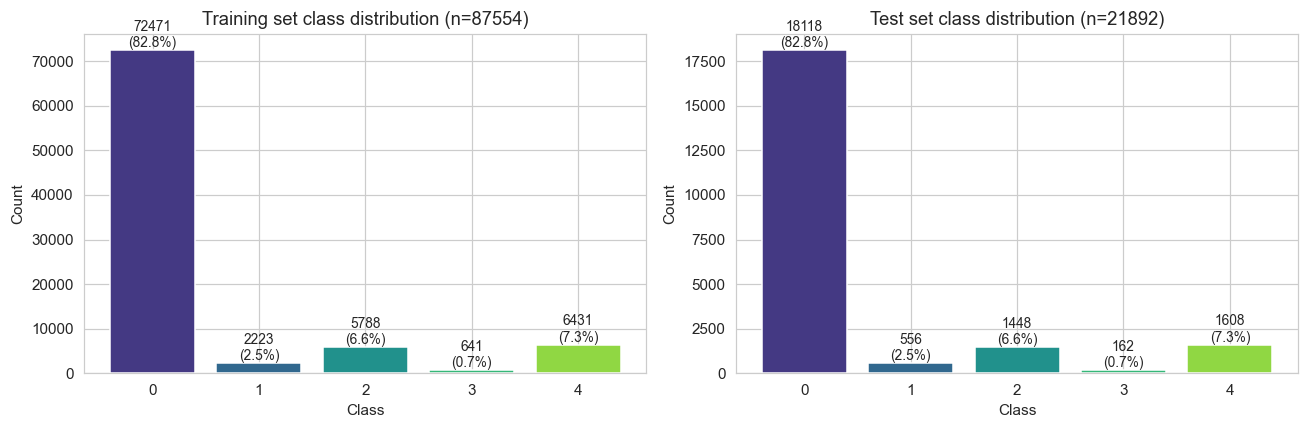

In [7]:
# Stage 4a: Class distribution bar charts (train and test side by side)

class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown/Paced']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y, name in zip(axes, [y_train, y_test], ['Training', 'Test']):
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=sns.color_palette('viridis', 5))
    ax.set_title(f'{name} set class distribution (n={len(y)})')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    # annotate each bar with its count and percentage
    for i, v in enumerate(counts.values):
        ax.text(counts.index[i], v, f'{v}\n({100*v/len(y):.1f}%)',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### 4b. Representative heartbeat per class

Plotting one beat from each class shows the morphological differences the model must learn:
peak position, secondary deflections, signal duration. These local-in-time patterns are
exactly what 1D convolutions are designed to detect — the justification for choosing a CNN.

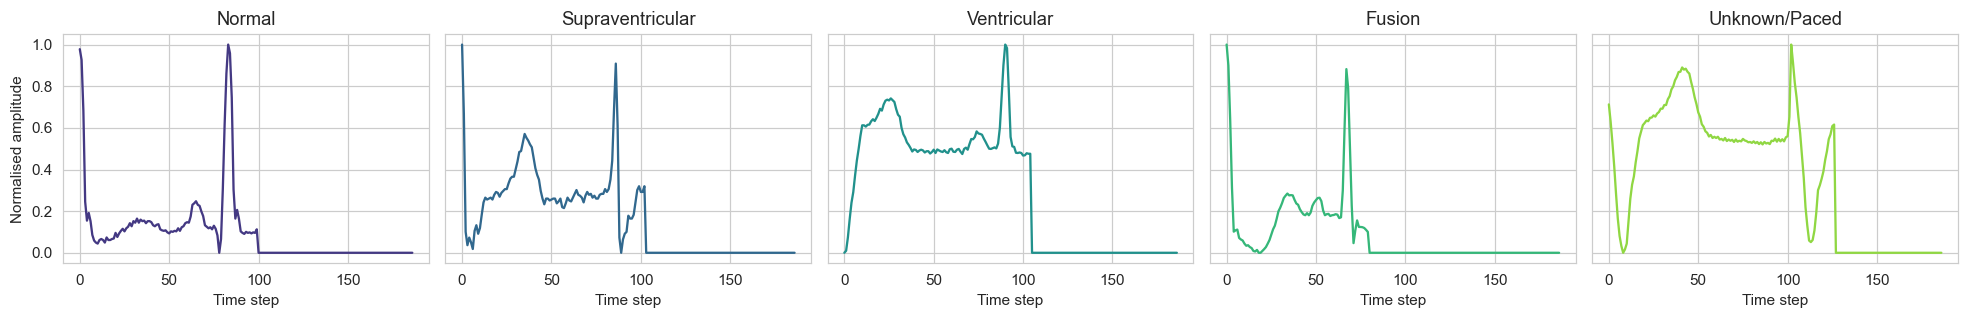

In [8]:
# Stage 4b: Plot one representative beat from each class

fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)

for c in range(5):
    # find the first sample belonging to class c
    idx = np.where(y_train == c)[0][0]
    # X_train is (N, 187, 1) now, so .squeeze() drops the trailing 1 for plotting
    axes[c].plot(X_train[idx].squeeze(), color=sns.color_palette('viridis', 5)[c])
    axes[c].set_title(class_names[c])
    axes[c].set_xlabel('Time step')

axes[0].set_ylabel('Normalised amplitude')
plt.tight_layout()
plt.savefig('fig_sample_beats.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Stage 5 — Model Architecture (1D CNN)

We use a 1D Convolutional Neural Network. ECG beats are time series whose discriminative
features (QRS complex shape, secondary deflections, durations) are *local in time* — exactly
what 1D convolutions capture. This inductive bias makes a CNN more suitable than an MLP
(which ignores temporal order) or an LSTM (slower, with no clear accuracy benefit here for
fixed-length beats).

**Design:** three convolutional blocks (Conv1D → BatchNorm → ReLU → MaxPool → Dropout) with
increasing filter counts (32 → 64 → 128), followed by Global Average Pooling, a dense layer,
and a softmax output. The builder is parameterised so the same code supports the
hyperparameter search in Stage 7.

In [9]:
# Stage 5: Define the 1D CNN architecture

def build_cnn(input_len=187, num_classes=5,
              filters=(32, 64, 128), kernel_size=5,
              dropout=0.3, dense_units=64, learning_rate=1e-3):
    """
    Build and compile a 1D CNN for ECG beat classification.

    Parameters (all tunable in Stage 7's hyperparameter search):
      input_len     : length of the input signal (187)
      num_classes   : number of output classes (5)
      filters       : tuple of filter counts, one per conv block
      kernel_size   : width of each convolutional filter
      dropout       : dropout rate applied after each block and the dense layer
      dense_units   : size of the penultimate dense layer
      learning_rate : Adam optimiser step size
    """
    inputs = layers.Input(shape=(input_len, 1))
    x = inputs

    # Convolutional blocks
    for f in filters:
        x = layers.Conv1D(f, kernel_size=kernel_size, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Dropout(dropout)(x)

    # Collapse the time dimension by averaging — fewer params than Flatten + Dense
    x = layers.GlobalAveragePooling1D()(x)

    # Dense head
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Assemble and compile
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',   # pairs with one-hot labels + softmax
        metrics=['accuracy'],
    )
    return model

# Build one instance with default hyperparameters and inspect it
demo_model = build_cnn()
demo_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 93, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,061 (238.52 KB)

 Trainable params: 60,613 (236.77 KB)

 Non-trainable params: 448 (1.75 KB)

### 5b. Architecture diagram

An auto-generated diagram of the layer structure. (For the final report this is supplemented
with a hand-drawn block diagram showing the data-shape transformations.)

Saved fig_architecture_auto.png


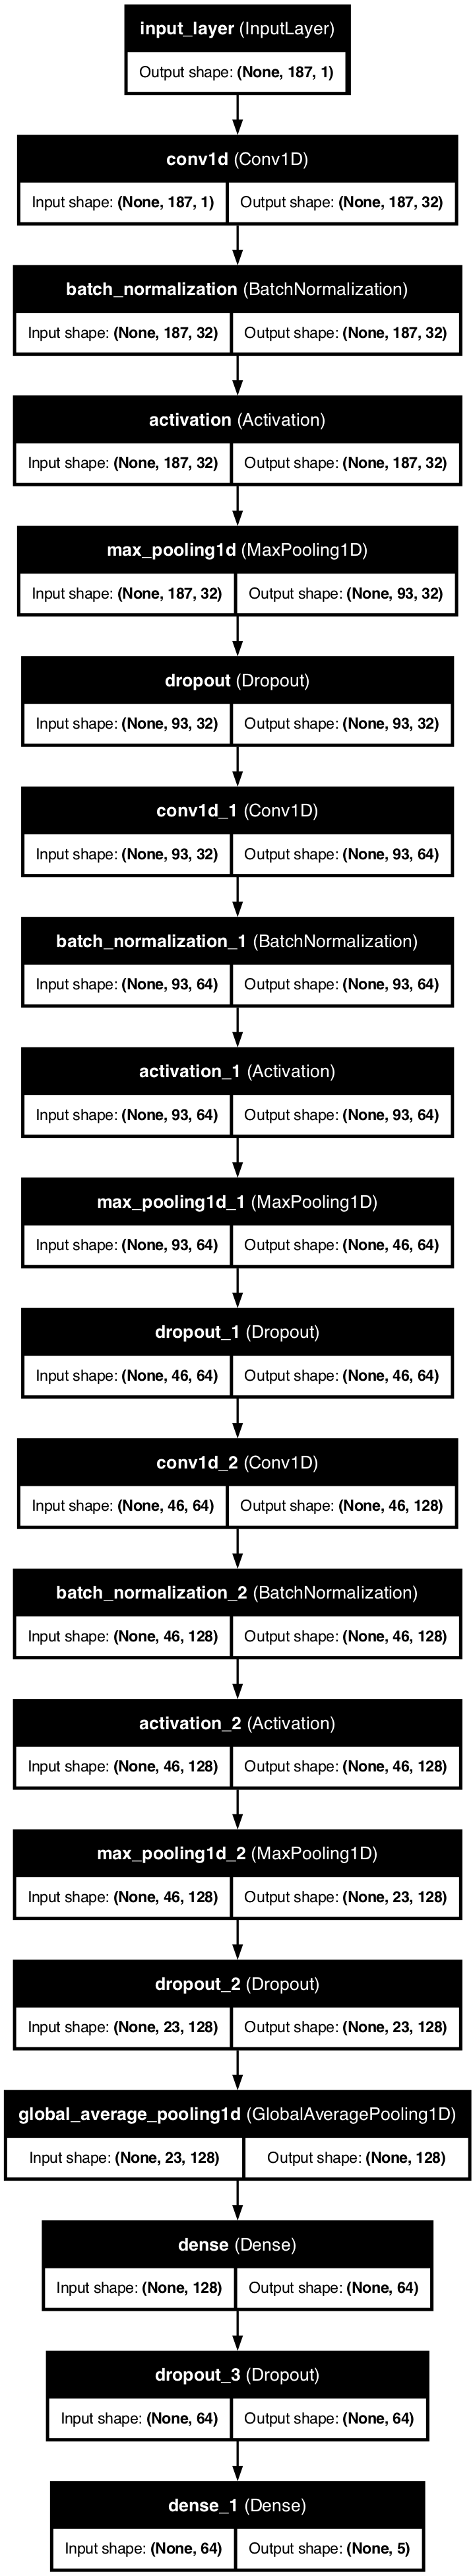

In [11]:
# Stage 5b: Auto-generate an architecture diagram
# Needs graphviz; if it fails, we fall back to the text summary (and draw by hand later).
try:
    plot_model(
        demo_model,
        to_file='fig_architecture_auto.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',     # top-to-bottom; use 'LR' for left-to-right
        dpi=120,
    )
    print('Saved fig_architecture_auto.png')
    from IPython.display import Image
    display(Image('fig_architecture_auto.png'))
except Exception as e:
    print('Could not auto-generate diagram (graphviz not installed?):', e)
    print('No problem — we will hand-draw the architecture figure for the report.')

In [12]:
demo_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 93, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,061 (238.52 KB)

 Trainable params: 60,613 (236.77 KB)

 Non-trainable params: 448 (1.75 KB)

---
## Stage 6 — Class Weights for Imbalance

Given the 113× imbalance between the largest (Normal) and smallest (Fusion) classes, an
unweighted model would minimise loss by predicting "Normal" almost everywhere. We weight the
loss inversely with class frequency so errors on rare classes are penalised more heavily.

We apply **square-root tempering** to the standard inverse-frequency weights. The raw weights
(up to ~27× for Fusion) are so aggressive they destabilise early training; the square root
preserves the relative ordering while compressing the dynamic range, giving stable training
that still strongly favours the minority classes.

In [13]:
# Stage 6: Compute square-root-tempered class weights

# Standard "balanced" inverse-frequency weights from sklearn
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)

# Square-root tempering: keep the ordering, compress the range
class_weights = {i: float(np.sqrt(w)) for i, w in enumerate(raw_weights)}

# Show both for comparison (and for the report)
print('Class | Count  | Raw weight | Tempered weight')
print('-' * 50)
counts = np.bincount(y_train, minlength=NUM_CLASSES)
for i in range(NUM_CLASSES):
    print(f'  {i}   | {counts[i]:6d} |   {raw_weights[i]:6.2f}   |     {class_weights[i]:5.2f}')

print('\nclass_weights dict passed to training:')
print(class_weights)

Class | Count  | Raw weight | Tempered weight
--------------------------------------------------
  0   |  72471 |     0.24   |      0.49
  1   |   2223 |     7.88   |      2.81
  2   |   5788 |     3.03   |      1.74
  3   |    641 |    27.32   |      5.23
  4   |   6431 |     2.72   |      1.65

class_weights dict passed to training:
{0: 0.49155358388725223, 1: 2.806617717813582, 2: 1.7393570132743923, 3: 5.226656743811354, 4: 1.650113202508115}


---
## Stage 7 — K-Fold Cross-Validation + Hyperparameter Search

We tune hyperparameters using **random search** (more efficient than grid search per
Bergstra & Bengio, 2012), evaluating each configuration with **stratified 5-fold
cross-validation**. Stratification preserves class proportions in every fold, which is
essential under severe imbalance. The configuration with the highest mean validation
accuracy across folds is selected for final training in Stage 8.

In [14]:
# Stage 7a: Define the hyperparameter search space

search_space = {
    'learning_rate': [1e-3, 5e-4, 1e-4],   # Adam step size
    'dropout':       [0.2, 0.3, 0.4],       # regularisation strength
    'kernel_size':   [3, 5, 7],             # width of conv filters
    'batch_size':    [64, 128, 256],        # samples per gradient update
}

# --- Search budget ---
# For a quick test on Mac CPU, set these small (e.g. 1, 2, 2).
# For the real run on Windows GPU, use the full values below.
N_CONFIGS = 6      # number of random configurations to try
N_FOLDS   = 5      # k in k-fold cross-validation
CV_EPOCHS = 12     # epochs per fold during the search

# Sample N_CONFIGS random configurations (reproducible thanks to the seed)
rng = np.random.default_rng(SEED)
def sample_config():
    return {k: rng.choice(v).item() for k, v in search_space.items()}

configs = [sample_config() for _ in range(N_CONFIGS)]
print(f'Search budget: {N_CONFIGS} configs x {N_FOLDS} folds x up to {CV_EPOCHS} epochs')
print(f'\nConfigurations to evaluate:')
for i, c in enumerate(configs):
    print(f'  Config {i}: {c}')

Search budget: 6 configs x 5 folds x up to 12 epochs

Configurations to evaluate:
  Config 0: {'learning_rate': 0.001, 'dropout': 0.4, 'kernel_size': 5, 'batch_size': 128}
  Config 1: {'learning_rate': 0.0005, 'dropout': 0.4, 'kernel_size': 3, 'batch_size': 256}
  Config 2: {'learning_rate': 0.001, 'dropout': 0.2, 'kernel_size': 5, 'batch_size': 256}
  Config 3: {'learning_rate': 0.0001, 'dropout': 0.4, 'kernel_size': 7, 'batch_size': 256}
  Config 4: {'learning_rate': 0.0005, 'dropout': 0.2, 'kernel_size': 7, 'batch_size': 128}
  Config 5: {'learning_rate': 0.0005, 'dropout': 0.3, 'kernel_size': 3, 'batch_size': 256}


In [15]:
# Stage 7b: Cross-validation routine for one configuration

def run_cv(config, X, y_int, y_oh, n_folds=5, epochs=12,
           class_weights=None, verbose=0):
    """
    Evaluate one hyperparameter config using stratified k-fold CV.
    Returns: mean val accuracy, std of val accuracy, list of per-fold histories.
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    fold_accuracies = []
    fold_histories  = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_int)):
        tf.keras.backend.clear_session()   # free memory between folds

        model = build_cnn(
            input_len=X.shape[1],
            num_classes=NUM_CLASSES,
            kernel_size=int(config['kernel_size']),
            dropout=float(config['dropout']),
            learning_rate=float(config['learning_rate']),
        )

        # stop early if validation loss stops improving (saves time, avoids overfitting)
        es = callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                     restore_best_weights=True)

        history = model.fit(
            X[tr_idx], y_oh[tr_idx],
            validation_data=(X[va_idx], y_oh[va_idx]),
            epochs=epochs,
            batch_size=int(config['batch_size']),
            class_weight=class_weights,
            callbacks=[es],
            verbose=verbose,
        )

        best_val_acc = max(history.history['val_accuracy'])
        fold_accuracies.append(best_val_acc)
        fold_histories.append(history.history)
        print(f'    Fold {fold+1}/{n_folds}: val_acc = {best_val_acc:.4f}')

    return float(np.mean(fold_accuracies)), float(np.std(fold_accuracies)), fold_histories

In [16]:
# Stage 7c: Run the random search (THE SLOW PART — use Windows GPU for the full run)

results = []
search_start = time.time()

for i, cfg in enumerate(configs):
    print(f'\n=== Config {i+1}/{len(configs)}: {cfg} ===')
    cfg_start = time.time()
    mean_acc, std_acc, histories = run_cv(
        cfg, X_train, y_train, y_train_oh,
        n_folds=N_FOLDS, epochs=CV_EPOCHS, class_weights=class_weights
    )
    results.append({
        'config': cfg,
        'mean_val_acc': mean_acc,
        'std_val_acc': std_acc,
        'histories': histories,
    })
    print(f'  >>> mean val_acc = {mean_acc:.4f} +/- {std_acc:.4f}  '
          f'({time.time()-cfg_start:.0f}s)')

print(f'\nTotal search time: {time.time()-search_start:.0f}s')

# Build a results table sorted best-first
summary = pd.DataFrame([
    {**r['config'], 'mean_val_acc': r['mean_val_acc'], 'std_val_acc': r['std_val_acc']}
    for r in results
]).sort_values('mean_val_acc', ascending=False).reset_index(drop=True)

summary.to_csv('cv_results.csv', index=False)   # save for the report
print('\n=== Hyperparameter search results (best first) ===')
print(summary.to_string(index=False))


=== Config 1/6: {'learning_rate': 0.001, 'dropout': 0.4, 'kernel_size': 5, 'batch_size': 128} ===
    Fold 1/5: val_acc = 0.9555
    Fold 2/5: val_acc = 0.9498
    Fold 3/5: val_acc = 0.9592
    Fold 4/5: val_acc = 0.9270


KeyboardInterrupt: 

In [ ]:
# Stage 7d: Select best config and plot its cross-validation learning curves

best_idx = int(np.argmax([r['mean_val_acc'] for r in results]))
best_config = results[best_idx]['config']
best_histories = results[best_idx]['histories']

print('Best configuration:', best_config)
print(f"Best mean CV accuracy: {results[best_idx]['mean_val_acc']:.4f} "
      f"+/- {results[best_idx]['std_val_acc']:.4f}")

# Plot loss and accuracy curves across the 5 folds for the best config
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for fold, h in enumerate(best_histories):
    axes[0].plot(h['loss'],     alpha=0.7, label=f'fold {fold+1} train')
    axes[0].plot(h['val_loss'], alpha=0.7, linestyle='--', label=f'fold {fold+1} val')
    axes[1].plot(h['accuracy'],     alpha=0.7, label=f'fold {fold+1} train')
    axes[1].plot(h['val_accuracy'], alpha=0.7, linestyle='--', label=f'fold {fold+1} val')

axes[0].set_title('CV loss curves (best config)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title('CV accuracy curves (best config)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('fig_cv_curves.png', bbox_inches='tight', dpi=150)
plt.show()